In [80]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [102]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda:None
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),"+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
        return self * -1
    def __sub__(self,other):
        return self + (-other)
    def __radd__(self,other):
        return self +other
        

    def __mul__(self,other):
        other = other if isinstance (other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __div__(self,other):
        out = Value(self.data / other.data,(self,other),"/")
        return out
    def __pow__(self,other):
        assert isinstance (other,(int,float)), "only supporting int /float pweers for now"
        out  = Value(self.data ** other , (self,),f'**{other}')
        def _backward():
            self.grad += other * self.data **(other-1) * out.grad
            
        out._backward = _backward
        return out
    def __rmul__(self,other):
        return self*other
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    def __truediv__(self,other):
        return self * other **-1
        
    def backward(self):
        topo =[]
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()
                
            
    
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b; e.label='e'
d = e +c; d.label='d'
f = Value(-2.0,label='f')
L = f*d; L.label = 'L'
L


Value(data=-8.0)

In [56]:
z = Value(3.0)
z+1

Value(data=4.0)

In [57]:
z*3

Value(data=9.0)

In [58]:
3*z

Value(data=9.0)

In [59]:
a = Value(2.0)
b = Value(3.0)
a-b

Value(data=-1.0)

In [60]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

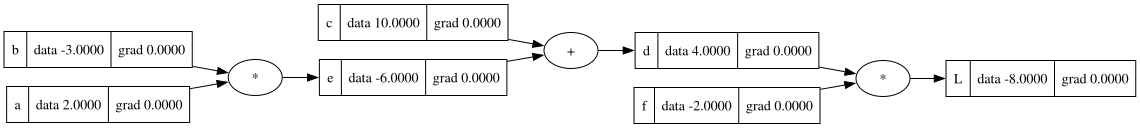

In [61]:
draw_dot(L)

In [62]:
L.grad =1.0
f.grad = 4.0
d.grad = -2.0

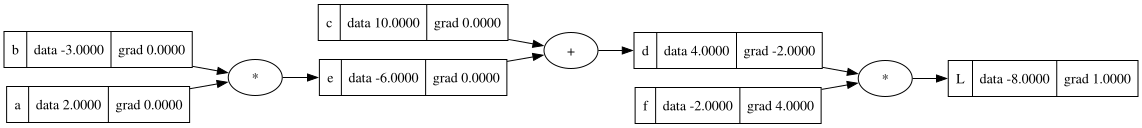

In [63]:
draw_dot(L)

In [64]:
def lol():
    h=0.001
    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a*b; e.label='e'
    d = e +c; d.label='d'
    f = Value(-2.0,label='f')
    L = f*d; L.label = 'L'
    L1 = L.data

    a = Value(2.0+h,label='a')
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a*b ; e.label='e'
    d = e +c; d.label='d'
    f = Value(-2.0,label='f')
    L = f*d ; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)

lol()

6.000000000000227


In [65]:
lr=0.01
a.data += lr*a.grad
b.data += lr*b.grad
c.data += lr*c.grad
f.data += lr*f.grad

e = a*b
d = e +c
L = f*d
L

Value(data=-31.36)

# more complex from now on

In [66]:
#input
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights =
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias
b = Value(6.8813,label='b')
#x1*w1 x2*w2
x1w1 = x1*w1 ;x1w1.label='x1w1'
x2w2 = x2*w2 ;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'

n=x1w1x2w2 +b; n.label='n'
o=n.tanh();o.label = 'o'

# draw_dot(o)
o.backward()

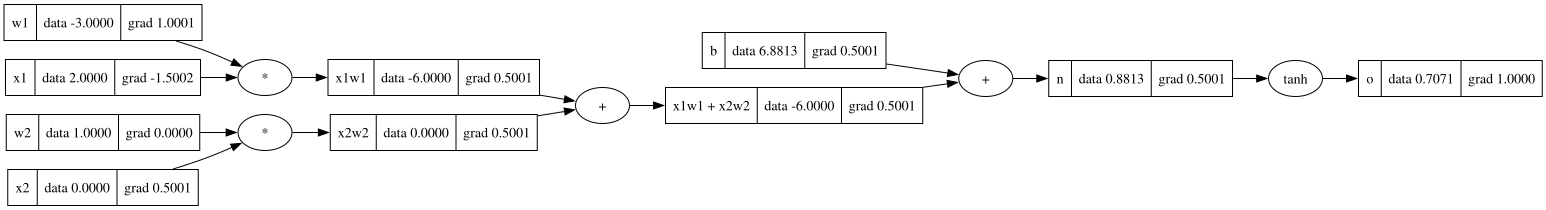

In [67]:
draw_dot(o)

In [71]:
#input
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights =
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias
b = Value(6.8813,label='b')
#x1*w1 x2*w2
x1w1 = x1*w1 ;x1w1.label='x1w1'
x2w2 = x2*w2 ;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'

n=x1w1x2w2 +b; n.label='n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'

# draw_dot(o)
o.backward()

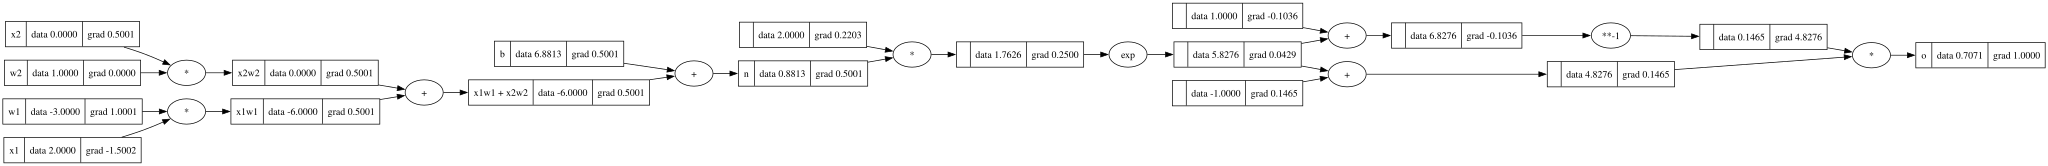

In [72]:
draw_dot(o)

# Doing same using pytorch

In [73]:
import torch

In [75]:
x1 = torch.tensor([2.0]).double()  ;   x1.requires_grad = True
w1 = torch.tensor([-3.0]).double() ;   w1.requires_grad = True
x2 = torch.tensor([0.0]).double()  ;   x2.requires_grad = True
w2 = torch.tensor([1.0]).double()  ;   w2.requires_grad = True
b  = torch.tensor([6.8813]).double() ;  b.requires_grad = True
n  = x1*w1 + x2*w2 + b 
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(x1.grad.item())


0.7070699720278941
-1.5001561639694192


In [213]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
      return self.w + [self.b]
  
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
      return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
  def __init__(self,nin,nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
  def __call__(self,x):
    for layer in self.layers:
        x= layer(x)
    return x
  def parameters(self):
      return [p for layer in self.layers for p in layer.parameters()]




In [342]:
x =[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)
        

Value(data=0.6183942831620273)

In [343]:
n.parameters()

[Value(data=-0.3413926975730046),
 Value(data=-0.45946754909242205),
 Value(data=-0.6259623767969684),
 Value(data=-0.8205679340893279),
 Value(data=0.5144187643672802),
 Value(data=-0.5616360471132824),
 Value(data=-0.30321088527791495),
 Value(data=-0.15534573203412116),
 Value(data=-0.7496852301161427),
 Value(data=-0.6301811504113521),
 Value(data=-0.2353027894156523),
 Value(data=-0.41046298145418847),
 Value(data=-0.24517322209072523),
 Value(data=-0.27927370313138566),
 Value(data=-0.5425809784059241),
 Value(data=0.30209896326631647),
 Value(data=-0.58997782194066),
 Value(data=0.4654885867945906),
 Value(data=-0.17940397837758337),
 Value(data=-0.785320701715001),
 Value(data=-0.1206089288314054),
 Value(data=0.906538565318278),
 Value(data=-0.84185210473007),
 Value(data=-0.5801822191376789),
 Value(data=-0.2036092359873738),
 Value(data=-0.2993082711985766),
 Value(data=-0.7306882247049533),
 Value(data=0.25331978096896823),
 Value(data=-0.7343628544497935),
 Value(data=0.87

In [344]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [-.5,1.0,1.0],
    [1.0,1.0,-1.0]
]#four different inputs
ys = [1.0,-1.0,-1.0,1.0] # desired outputs


In [389]:

for k in range(50):
    #forward pass
    ypred = [n(x) for x in xs]
    loss=sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))
    loss
    # backward pass
    for p in n.parameters():
        p.grad =0.0
    loss.backward()
    #updates
    for p in n.parameters():
        p.data += -0.05*p.grad
    print(k,loss.data)
    
    
    

0 0.0007556784356612316
1 0.0007546822023335612
2 0.0007536885452151594
3 0.0007526974543947569
4 0.0007517089200116338
5 0.0007507229322553407
6 0.000749739481365391
7 0.0007487585576308939
8 0.0007477801513903039
9 0.0007468042530310605
10 0.000745830852989273
11 0.0007448599417494827
12 0.0007438915098442801
13 0.0007429255478540301
14 0.0007419620464065887
15 0.0007410009961769752
16 0.0007400423878871046
17 0.0007390862123054768
18 0.0007381324602468952
19 0.0007371811225721725
20 0.0007362321901878086
21 0.0007352856540457977
22 0.0007343415051432497
23 0.0007333997345221652
24 0.0007324603332691152
25 0.0007315232925150256
26 0.0007305886034348402
27 0.000729656257247268
28 0.0007287262452145571
29 0.0007277985586421484
30 0.0007268731888784704
31 0.0007259501273146579
32 0.0007250293653842592
33 0.0007241108945630277
34 0.0007231947063686245
35 0.0007222807923603736
36 0.0007213691441390177
37 0.0007204597533464504
38 0.0007195526116654656
39 0.0007186477108195095
40 0.00071774

In [390]:
ypred

[Value(data=0.9912236773060649),
 Value(data=-0.9857716149831387),
 Value(data=-0.9852092842094395),
 Value(data=0.9854575070152554)]